# Lab Instructions

Create 3 visualizations from text data of your choice.  Each visualization should have at least 1 - 2 sentences explaining both the figure and the interpretation.
You may use any LLM and produce whatever visuals you think best illustrate your data.  

# Google Play Store Productivity App Review Analysis

This project analyzes Google Play Store user reviews for mobile productivity applications. The goal of this analysis is to identify what users value most in productivity apps, what issues lead to negative reviews, and how review sentiment relates to the way users describe their experiences.

The dataset includes Google Play Store app information and user review text. The data was filtered to include only apps in the **PRODUCTIVITY** category.

Data Set From

L. Gupta, "Google Play Store Apps," Feb 2019. [Online]. Available: https://www.kaggle.com/lava18/google-play-store-apps

# Data Preparation

Before beginning the analysis, the required Python libraries are imported and the Natural Language Toolkit (NLTK) resources are downloaded. These libraries provide the tools necessary for loading the dataset, processing review text, performing sentiment analysis, removing stop words, and creating visualizations.

The analysis uses:
- **Pandas** for data manipulation
- **NumPy** for numerical operations
- **Matplotlib** and **Plotly** for visualizations
- **WordCloud** for text visualization
- **TextBlob** for sentiment analysis
- **NLTK** for tokenization, stop words, and part-of-speech tagging

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from wordcloud import WordCloud
from textblob import TextBlob

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import re

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/greghudler/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/greghudler/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [78]:
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/greghudler/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [79]:
nltk.download("averaged_perceptron_tagger")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/greghudler/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [80]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/greghudler/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/greghudler/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/greghudler/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/greghudler/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

# Data Loading and Preprocessing

The Google Play Store application dataset and user review dataset are loaded into separate DataFrames and merged using the application name as the common key. The merged dataset is then filtered to include only applications within the **Productivity** category. Reviews with missing translated text are removed to ensure all subsequent analyses are based on complete review data. Finally, customized stop word lists are created to improve text mining by removing common words that do not contribute meaningful insights while preserving important productivity-related terminology.

In [81]:
apps_df = pd.read_csv("googleplaystore.csv")
reviews_df = pd.read_csv("googleplaystore_user_reviews.csv")

In [82]:
merged_df = pd.merge(
    reviews_df,
    apps_df,
    on="App",
    how="inner"
)

In [83]:
productivity_df = merged_df[
    merged_df["Category"] == "PRODUCTIVITY"
].copy()

In [84]:
productivity_df = productivity_df.dropna(
    subset=["Translated_Review"]
)

In [85]:
from nltk.corpus import stopwords

base_stop_words = set(stopwords.words("english"))

shared_stopwords = {

    # Generic app words
    "app","apps","application","android","phone",

    # Generic verbs
    "use","used","using","work","works","working","get","got","make","makes","made",
    "find","found","take","takes","put","bring","provide","provides","allow","allows",
    "send","create","move","read","check","delete","deleted","save","saved",
    "record","recording",

    # Conversational filler
    "really","also","one","can","could","would","will","just","ever","never","always",
    "still","even","well","much","way","go","back","see","say","know","try","tried",
    "able","without","can't",

    # Review words
    "review","reviews","feature","features","option","options","version","versions",
    "update","updates","rating",

    # Generic positive words
    "good","great","nice","best","love","amazing","awesome","perfect","excellent",
    "help","helps","thank","thanks","please",

    # Generic nouns
    "people","person","someone","users","user","guys","others","thing","things",
    "something","anything","everything","reason","information","idea","ideas",
    "part","kind","life","lot",

    # Time words
    "time","times","day","days","month","months","year","years","today","date","dates",
    "every","daily","soon","latest",

    # UI words
    "screen","page","pages","view","views","viewer","mode","home","open","reader",
    "keyboard","color","key","word","words","text",

    # Generic computer words
    "device","devices","document","documents","data","images","photo","photos",
    "software","function",

    # Misc
    "problem","problems","issue","issues","ability","space","size","account","job",
    "call","team","type","etc","sd","card","ui","auto","look","shows","show","store",
    "print","location","understand","installed","downloaded","wanted","possible",
    "another","otherwise","several","enough","next","far","special","important",
    "huge","need","want","wish","think","many","two","first","last","ago","since",
    "recent","old","new","however","especially","sure","must","let","top","fine",
    "right","plus","entire","different","pretty","long","little","quickly",
    "absolutely","like",

    # Brand names
    "google","adobe","acrobat","dropbox","evernote","asus","amazon","htc","chrome",
    "pdf","pdfs","drive","slides","widget","keep","colornote","facebook","huawei",
    "samsung","avg","pc","galaxy"
}

positive_stop_words = base_stop_words.union(shared_stopwords)

negative_extra_stopwords = {

    # Positive features
    "note","notes","list","lists","file","files","folder","folders","cloud","storage",
    "search","task","tasks","calendar","email","notification","notifications",
    "password","backup","sync","share","shared","edit","write","writing","copy",
    "checkbox","upload","scan","access","title","reminder","reminders",

    # Positive descriptors
    "easy","simple","useful","free","better","fast","add",

    # Generic filler
    "shopping","trying","making","getting","tell","said","means","come","gets",
    "give","via","may","actually","exactly","else","least","second","multiple",
    "previous","started","start","keeping","keeps","thought",

    # UI / generic
    "window","background","details","characters","group","manager","collection",
    "service","design","videos","watch","online","period",

    # Devices / brands
    "windows","iphone","laptop","novo","a5","sta",

    # Random junk
    "ass","damn","ya","ya'll","je","pro","pop","g",

    # Misc
    "book","theme","video","pictures","black","green","icon","select","single",
    "specific","similar","future","finally","fact","perhaps","everyone","stop",
    "full","paste","p20"
}

negative_stop_words = base_stop_words.union(
    shared_stopwords,
    negative_extra_stopwords
)

In [86]:
from collections import Counter
import re

words = re.findall(r"\b[a-zA-Z]+\b", text.lower())

filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

word_counts = Counter(filtered_words)

# Text Mining and Sentiment Visualization

To better understand the language used by reviewers, word cloud visualizations were generated for both positive and negative reviews. Custom stop word lists were developed to remove common words, brand names, and filler terms that did not contribute meaningful insights. This allowed the visualization to emphasize the features, functionality, and experiences that users most frequently discussed. The resulting word clouds provide a high-level summary of the dominant themes associated with positive and negative sentiment within productivity application reviews.

## Positive Review Word Cloud

The positive review word cloud highlights the words that appear most frequently in favorable user reviews after preprocessing and stop word removal. Larger words indicate terms that occur more often, revealing the features and qualities users value most in productivity applications.

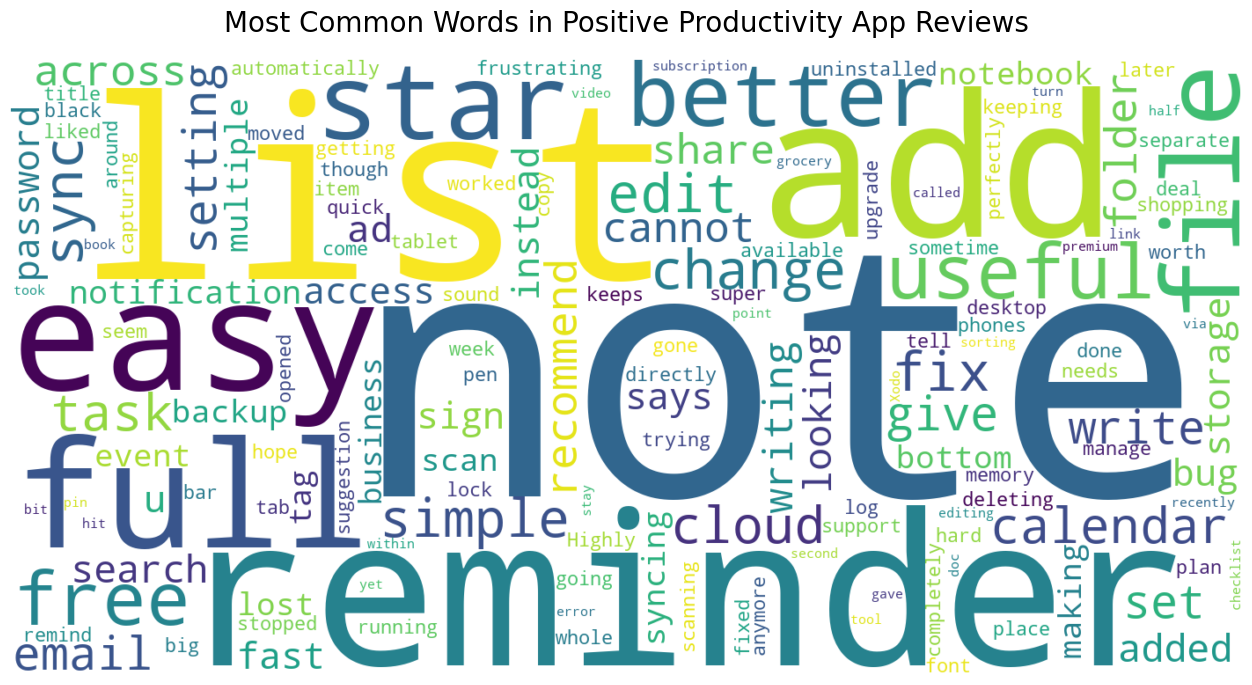

In [87]:
# Get only positive reviews
positive_reviews = productivity_df[
    productivity_df["Sentiment"] == "Positive"
]["Translated_Review"]

# Combine all reviews into one string
text = " ".join(positive_reviews.astype(str))

# Generate the word cloud
wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    stopwords=positive_stop_words,
    collocations=False,      # Prevents phrases like "take notes" from becoming one word
    max_words=150,
    min_font_size=10
).generate(text)

# Display the visualization
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Most Common Words in Positive Productivity App Reviews",
    fontsize=20,
    pad=20
)
plt.show()

### Interpretation

The positive review word cloud reveals that users consistently associate productivity applications with note-taking and organizational features. The most prominent terms include **note**, **reminder**, **list**, **easy**, **full**, and **useful**, indicating that users place significant value on applications that simplify task management and daily organization.

Several feature-specific words such as **calendar**, **notification**, **sync**, **cloud**, **backup**, **search**, **password**, and **email** also appear frequently. This suggests that users appreciate applications that synchronize information across devices, provide reliable storage, and integrate multiple productivity tools into a single platform.

The presence of words such as **easy**, **simple**, **better**, **fast**, and **free** indicates that ease of use, performance, and accessibility are important contributors to positive user experiences. Overall, the visualization suggests that positive reviews focus primarily on functionality, convenience, and reliability rather than aesthetic features.

## Negative Review Word Cloud

The negative review word cloud highlights the most common terms found in unfavorable user reviews. By filtering out generic application terminology, the visualization focuses on recurring complaints and pain points, making it easier to identify common usability issues, software defects, and areas where users expressed dissatisfaction.

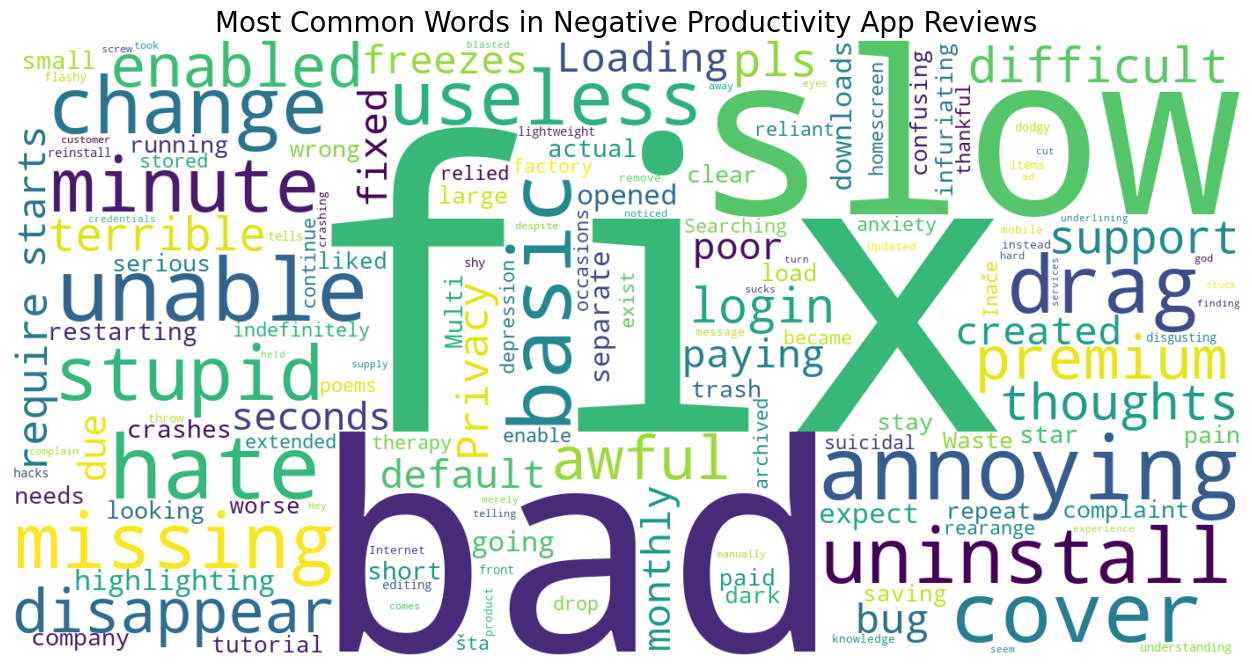

In [88]:
# Get only negative reviews
negative_reviews = productivity_df[
    productivity_df["Sentiment"] == "Negative"
]["Translated_Review"]

negative_text = " ".join(negative_reviews.astype(str))

negative_wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    stopwords=negative_stop_words,
    collocations=False,
    max_words=150
).generate(negative_text)

plt.figure(figsize=(16,8))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Negative Productivity App Reviews", fontsize=20)
plt.show()

### Interpretation

The negative review word cloud highlights the most common issues reported by users of productivity applications. The largest terms include **bad**, **slow**, **fix**, **unable**, **missing**, **annoying**, **uninstall**, and **useless**, suggesting that technical problems and software reliability are the primary sources of dissatisfaction.

Performance-related words such as **slow**, **loading**, **freezes**, **crashes**, and **minute** indicate that users frequently experience lag, long loading times, and application instability. Additionally, words including **missing**, **disappear**, **unable**, and **change** suggest that users are frustrated by lost data, missing features, or functions that no longer work as expected after updates.

The appearance of words such as **premium**, **paying**, **support**, **login**, and **privacy** indicates that some negative reviews also focus on subscription models, account access, customer support, and privacy concerns. Overall, the visualization suggests that users are less concerned with the availability of features and more concerned with application stability, reliability, and performance. These factors appear to have the greatest impact on negative user sentiment.

## Top 20 Most Frequent Words in Positive Reviews

To complement the positive review word cloud, a frequency analysis was performed to identify the twenty most common words appearing in positive productivity app reviews. While the word cloud provides a visual overview of common themes, the bar chart makes it easier to compare the relative frequency of each term.

This visualization helps confirm which features and qualities users value most, such as note-taking, reminders, lists, synchronization, organization, and ease of use. Presenting the data in ranked order provides a clearer comparison of feature popularity and supports the observations made from the word cloud.

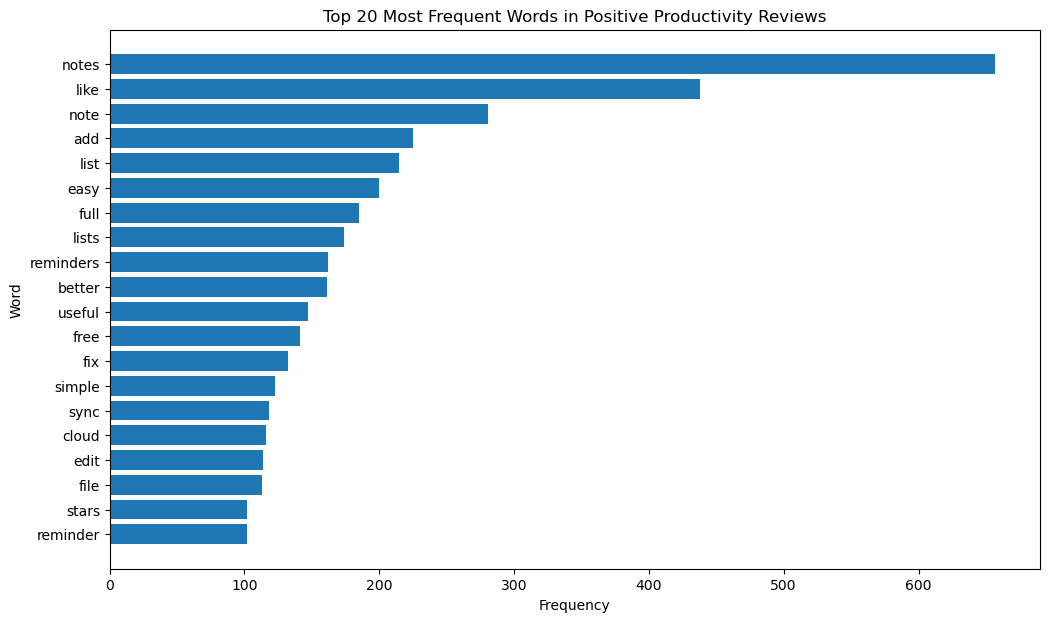

In [89]:
from collections import Counter
import re

words = re.findall(r"\b[a-zA-Z]+\b", text.lower())

filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

word_counts = Counter(filtered_words)

top20 = word_counts.most_common(20)

labels = [x[0] for x in top20]
counts = [x[1] for x in top20]

plt.figure(figsize=(12,7))
plt.barh(labels[::-1], counts[::-1])

plt.title("Top 20 Most Frequent Words in Positive Productivity Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

### Interpretation

The bar chart reinforces the findings from the positive review word cloud by showing the exact frequency of the most commonly used words in positive productivity app reviews. The highest-ranking words include **note**, **reminder**, **list**, **file**, and **easy**, indicating that users most frequently praise applications for helping them organize information and manage daily tasks.

The prominence of words such as **easy**, **useful**, **simple**, **sync**, and **cloud** suggests that reviewers value applications that are intuitive to use while also providing reliable synchronization and cloud storage across devices. Additionally, words like **calendar**, **task**, **search**, **backup**, and **notification** demonstrate that users appreciate productivity apps offering a comprehensive set of organizational tools rather than focusing on a single feature.

Overall, the chart indicates that positive reviews are driven by usability, organization, and reliability. Users are most satisfied with applications that make note-taking and task management simple while providing dependable synchronization, storage, and reminder capabilities.

## Sentiment Polarity vs. Subjectivity of Productivity App Reviews
This scatter plot visualizes the relationship between sentiment polarity and subjectivity for productivity app reviews. Sentiment polarity measures whether a review is positive or negative, while subjectivity measures whether the review expresses personal opinions or objective statements.

By plotting both measurements together and coloring reviews by sentiment, this visualization provides insight into not only how users feel about productivity applications, but also whether those opinions are based on personal experiences or more factual observations.

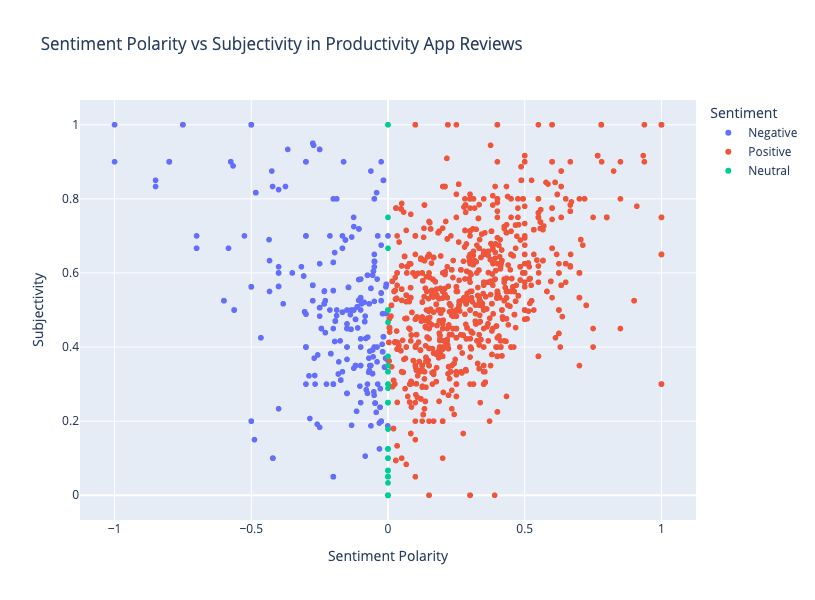

In [90]:
fig = px.scatter(
    productivity_df,
    x="Sentiment_Polarity",
    y="Sentiment_Subjectivity",
    color="Sentiment",
    hover_data=["App", "Translated_Review"],
    title="Sentiment Polarity vs Subjectivity in Productivity App Reviews",
    labels={
        "Sentiment_Polarity": "Sentiment Polarity",
        "Sentiment_Subjectivity": "Subjectivity"
    }
)

fig.update_layout(
    xaxis_title="Sentiment Polarity",
    yaxis_title="Subjectivity",
    height=600
)

fig.show()

### Interpretation

The scatter plot shows a clear separation between positive and negative reviews along the sentiment polarity axis. Most positive reviews cluster on the right side of the graph, while negative reviews are concentrated on the left, indicating that the sentiment analysis successfully distinguishes favorable and unfavorable opinions.

Most reviews also exhibit moderate to high subjectivity, suggesting that users primarily write from personal experience rather than presenting objective facts. Positive reviews generally describe how the applications improve productivity through features such as note-taking, reminders, synchronization, and organization. In contrast, negative reviews tend to focus on frustrations with bugs, missing functionality, crashes, and usability issues.

The visualization also reveals that both positive and negative reviews span a wide range of subjectivity levels. This indicates that users express both strong emotional reactions and more measured evaluations regardless of whether their overall sentiment is positive or negative. Overall, the chart demonstrates that user reviews are largely experience-driven while still providing a clear distinction between satisfied and dissatisfied users.

## Productivity App Review Length by Sentiment
This box plot compares the distribution of review lengths between positive and negative productivity app reviews. Review length was calculated as the total number of characters in each translated review.

By comparing the distributions, this visualization helps determine whether users who are satisfied or dissatisfied with productivity applications tend to leave longer and more detailed feedback.

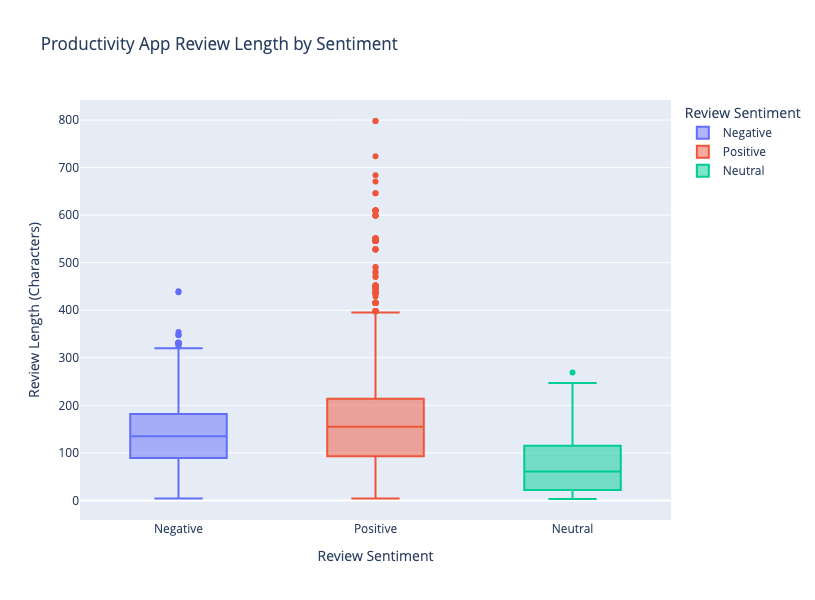

In [91]:
productivity_df["review_length"] = (
    productivity_df["Translated_Review"].str.len()
)

fig = px.box(
    productivity_df,
    x="Sentiment",
    y="review_length",
    color="Sentiment",
    title="Productivity App Review Length by Sentiment",
    labels={
        "review_length": "Review Length (Characters)",
        "Sentiment": "Review Sentiment"
    }
)

fig.update_layout(height=600)

fig.show()

### Interpretation

The box plot indicates that negative reviews are generally longer than positive reviews. The median review length for negative reviews is higher, and the distribution is noticeably wider, suggesting that dissatisfied users are more likely to provide detailed explanations of their experiences.

Negative reviews also contain more extreme outliers, indicating that some users write very lengthy reviews when describing bugs, crashes, missing features, or other frustrations. In contrast, positive reviews tend to be shorter and more consistent, often expressing satisfaction with the application's usability or specific features without requiring lengthy explanations.

Overall, this visualization suggests that users are more motivated to write detailed feedback when they encounter problems, while satisfied users typically leave shorter reviews focused on features they appreciate.